# 11 — Winton-style diversified trend and portable alpha

## 🧭 tl;dr

Winton publicly describes systematic trend following across major liquid markets and has also described combining trend exposure with passive global equity exposure. This notebook tests a diversified multi-speed trend ensemble and a simple 50/50 trend-plus-equity portable-alpha proxy. Neither is a replication of Winton's proprietary strategies.

> Educational research only. This notebook is not investment advice.

<div style="border-left: 5px solid #2563EB; padding: 0.85em 1em; margin: 1em 0 1.4em; background: #F8FAFC; border-radius: 8px;">
<strong>🧭 Reader guide</strong><br>
Start with the assumptions, then follow the data and rule definitions. The tables and charts report the formal test period. Finish with <strong>What went well / what went wrong</strong> — that is where the research judgment and limitations are made explicit.
</div>


## 🧭 Context & methods

A diversified trend ensemble combines several lookback speeds so the portfolio is not dependent on one exact definition of a trend. The portable-alpha version adds a fixed equity allocation to the trend sleeve, making the trade-off between diversification and market participation visible.

### Key assumptions

- The market set is `SPY`, `TLT`, `GLD`, `DBC`, `EFA`, and `EEM`, standing in for equities, bonds, commodities, and currencies/regions that a major-market trend program might access.
- Each trend sleeve uses 21, 63, 126, or 252 trading-day time-series momentum, monthly decisions, and a 10% volatility target. The ensemble averages the four sleeves.
- Portable alpha is 50% SPY buy-and-hold plus 50% of the trend ensemble. The model is unlevered and does not include fund fees, futures rolls, financing, collateral income, or implementation shortfall.
- The final 20% is an untouched formal test period; crisis windows are diagnostic only.

In [1]:
from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src.backtest import split_time_series
from src.data import load_price_panel, make_demo_ohlcv
from src.fund_strategies import volatility_scaled_time_series_momentum_weights
from src.portfolio import run_portfolio_backtest
from src.research import comparison_table, metrics_for_period

# Consistent visual language across the research library.
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 120,
    "savefig.dpi": 160,
    "axes.facecolor": "#F8FAFC",
    "axes.edgecolor": "#CBD5E1",
    "axes.grid": True,
    "grid.color": "#CBD5E1",
    "grid.alpha": 0.35,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelcolor": "#334155",
    "xtick.color": "#475569",
    "ytick.color": "#475569",
    "legend.frameon": False,
    "figure.autolayout": True,
})


## 📦 Data

The ETF panel is a practical proxy for a much larger futures and forward universe. That simplification is important when interpreting the results.

In [2]:
USE_DEMO_DATA = False
TRANSACTION_COST_BPS = 10
TICKERS = ['SPY', 'TLT', 'GLD', 'DBC', 'EFA', 'EEM']

if USE_DEMO_DATA:
    close = pd.concat([make_demo_ohlcv(periods=5_000, seed=i + 40, start='2006-01-01')['close'].rename(t) for i, t in enumerate(TICKERS)], axis=1)
else:
    try:
        close = load_price_panel(TICKERS, '2006-01-01', '2026-01-01')
    except Exception as exc:
        print(f'Live download unavailable ({type(exc).__name__}: {exc}); using deterministic demo data.')
        close = pd.concat([make_demo_ohlcv(periods=5_000, seed=i + 40, start='2006-01-01')['close'].rename(t) for i, t in enumerate(TICKERS)], axis=1)

splits = split_time_series(close, train_fraction=0.60, validation_fraction=0.20)
benchmark_returns = close['SPY'].pct_change().fillna(0.0)
print(f'Data: {close.index.min().date()} through {close.index.max().date()} ({len(close):,} common trading days)')

Data: 2006-02-06 through 2025-12-31 (5,008 common trading days)


## 📚 Public research and strategy translation

- [Winton: What is trend following?](https://www.winton.com/news/what-is-trend-following) describes systematic long/short trend rules, risk-proportional sizing, and diversification across stocks, bonds, commodities, and currencies.
- [Winton: Portable Alpha UCITS launch](https://www.winton.com/news/winton-portable-alpha-ucits-launches-today) describes combining a trend strategy with passive global equity exposure.

This notebook tests those public concepts with simple ETF rules. It does not claim access to Winton's research process, market breadth, execution technology, signal ensemble, or risk management.

In [3]:
lookbacks = [21, 63, 126, 252]
trend_sleeves = [
    volatility_scaled_time_series_momentum_weights(close, lookback=lookback, volatility_lookback=63, target_volatility=0.10)
    for lookback in lookbacks
]
trend_ensemble = sum(trend_sleeves) / len(trend_sleeves)
portable_alpha = trend_ensemble * 0.50
portable_alpha['SPY'] = portable_alpha['SPY'] + 0.50

spy_weights = pd.DataFrame(0.0, index=close.index, columns=close.columns)
spy_weights['SPY'] = 1.0
weights = {
    'SPY buy-and-hold control': spy_weights,
    'Winton-style trend ensemble': trend_ensemble,
    'Winton-style portable alpha': portable_alpha,
}
results = {
    name: run_portfolio_backtest(
        close, target_weights, transaction_cost_bps=TRANSACTION_COST_BPS, benchmark_returns=benchmark_returns
    )
    for name, target_weights in weights.items()
}
test_table = comparison_table(results, splits['test'].index)
test_table.style.format({
    'annualized_return': '{:.2%}', 'annualized_volatility': '{:.2%}', 'sharpe_ratio': '{:.2f}',
    'sortino_ratio': '{:.2f}', 'max_drawdown': '{:.2%}', 'calmar_ratio': '{:.2f}',
    'win_rate': '{:.2%}', 'annualized_turnover': '{:.2f}', 'number_of_trades': '{:.0f}',
    'total_return_after_costs': '{:.2%}', 'benchmark_relative_return': '{:.2%}',
})

,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,win_rate,annualized_turnover,number_of_trades,total_return_after_costs,benchmark_total_return,benchmark_relative_return
SPY buy-and-hold control,10.90%,18.01%,0.66,0.96,-24.47%,0.45,53.90%,0.00,0,50.91%,0.509089,0.00%
Winton-style trend ensemble,3.29%,6.91%,0.50,0.70,-15.29%,0.22,52.89%,5.07,48,13.74%,0.509089,-37.17%
Winton-style portable alpha,7.53%,9.60%,0.80,1.17,-11.82%,0.64,53.39%,2.54,48,33.48%,0.509089,-17.43%


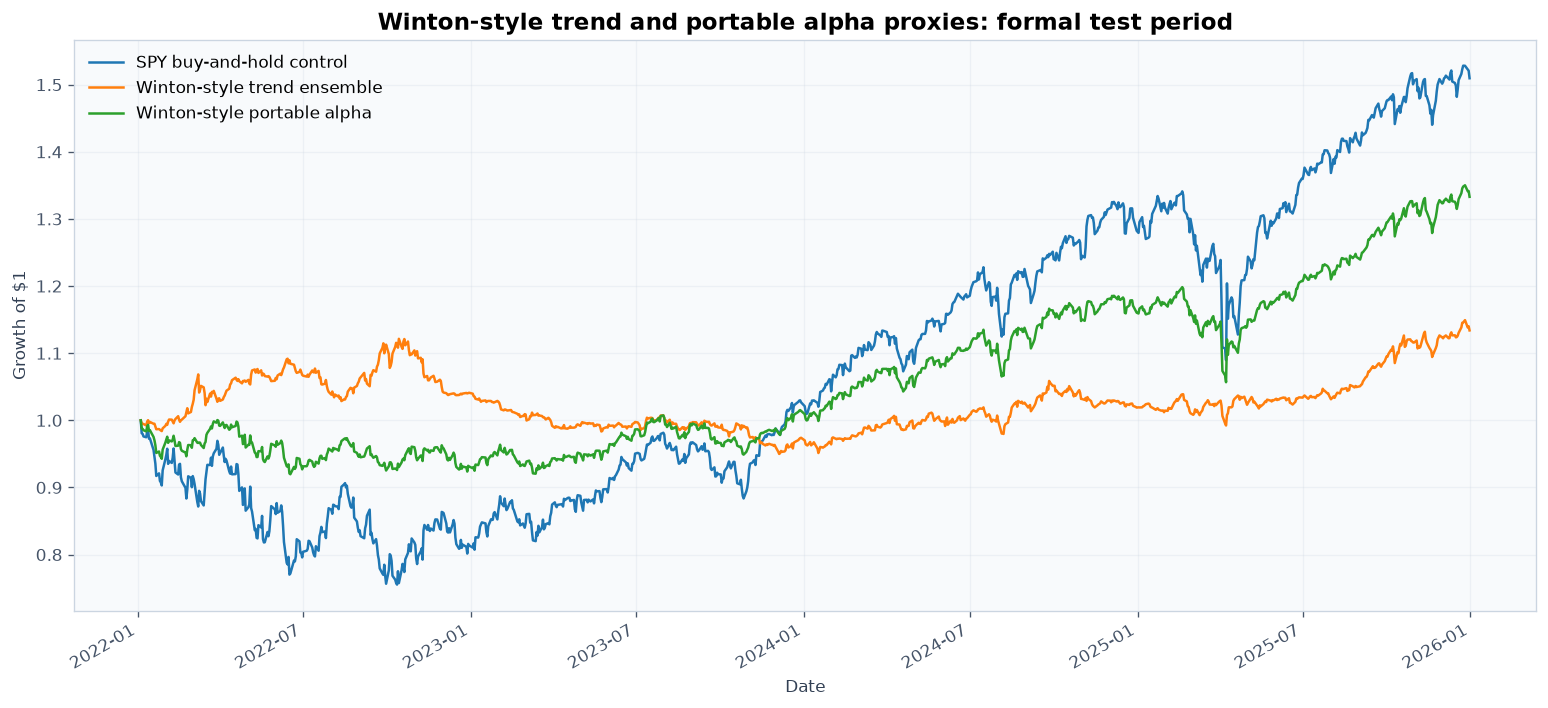

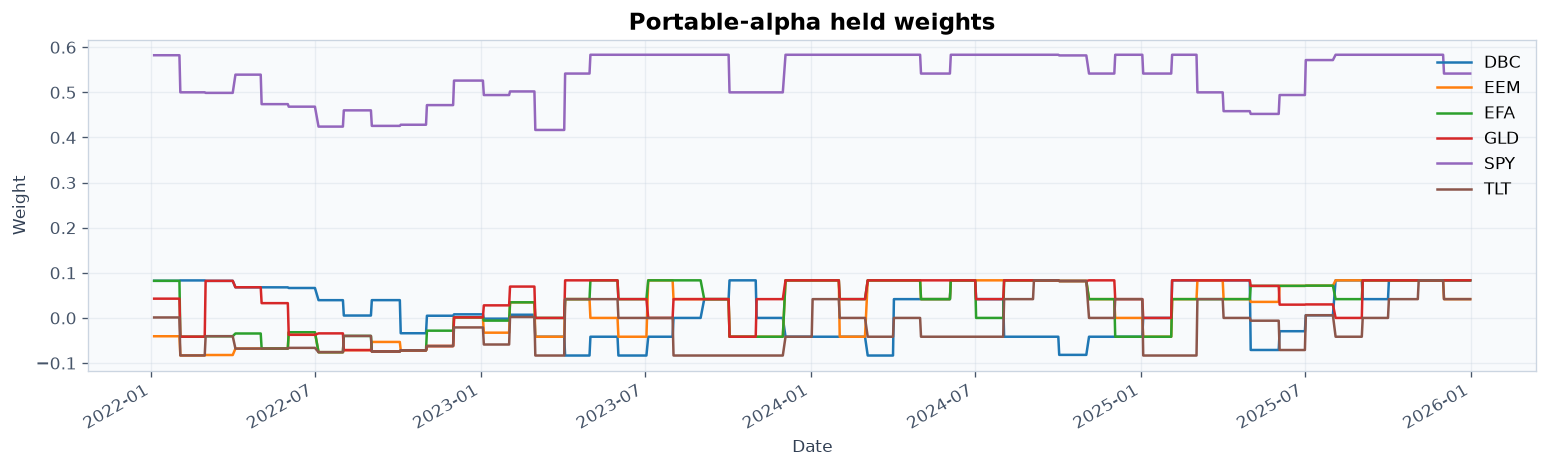

In [4]:
ax = None
for name, result in results.items():
    equity = result.frame['equity'].loc[splits['test'].index]
    ax = (equity / equity.iloc[0]).plot(ax=ax, figsize=(13, 6), label=name)
ax.set_title('Winton-style trend and portable alpha proxies: formal test period')
ax.set_ylabel('Growth of $1')
ax.grid(alpha=0.25)
ax.legend()
plt.show()

results['Winton-style portable alpha'].held_weights.loc[splits['test'].index].plot(figsize=(13, 4), title='Portable-alpha held weights')
plt.ylabel('Weight')
plt.show()

## 🛡️ Crisis and cost diagnostics

Trend strategies can be useful when a crisis becomes a sustained trend, while a portable-alpha sleeve deliberately retains equity exposure. Compare crisis return with drawdown and turnover rather than looking only at the full-sample Sharpe.

In [5]:
stress_windows = {'Global Financial Crisis': ('2007-10-01', '2009-03-31'), 'COVID shock': ('2020-02-19', '2020-03-23'), '2022 inflation/rates shock': ('2022-01-03', '2022-10-14')}
rows = []
for window, (start, end) in stress_windows.items():
    index = close.loc[start:end].index
    for name, result in results.items():
        returns = result.frame.loc[index, 'net_returns']
        equity = (1.0 + returns).cumprod()
        rows.append({'window': window, 'strategy': name, 'return': equity.iloc[-1] - 1.0 if len(equity) else float('nan'), 'max_drawdown': (equity / equity.cummax() - 1.0).min() if len(equity) else float('nan')})
stress_table = pd.DataFrame(rows)
display(stress_table.style.format({'return': '{:.2%}', 'max_drawdown': '{:.2%}'}))

cost_rows = []
for cost_bps in [0, 10, 25, 50]:
    for name, target_weights in weights.items():
        result = run_portfolio_backtest(close, target_weights, transaction_cost_bps=cost_bps, benchmark_returns=benchmark_returns)
        metrics = metrics_for_period(result, splits['test'].index)
        cost_rows.append({'strategy': name, 'cost_bps': cost_bps, 'test_return': metrics['total_return_after_costs'], 'test_sharpe': metrics['sharpe_ratio']})
cost_table = pd.DataFrame(cost_rows)
display(cost_table.style.format({'test_return': '{:.2%}', 'test_sharpe': '{:.2f}'}))

,window,strategy,return,max_drawdown
0,Global Financial Crisis,SPY buy-and-hold control,-45.96%,-55.19%
1,Global Financial Crisis,Winton-style trend ensemble,12.96%,-6.88%
2,Global Financial Crisis,Winton-style portable alpha,-18.51%,-25.92%
3,COVID shock,SPY buy-and-hold control,-33.40%,-33.72%
4,COVID shock,Winton-style trend ensemble,7.16%,-2.10%
5,COVID shock,Winton-style portable alpha,-14.62%,-14.85%
6,2022 inflation/rates shock,SPY buy-and-hold control,-23.83%,-24.50%
7,2022 inflation/rates shock,Winton-style trend ensemble,12.49%,-5.78%
8,2022 inflation/rates shock,Winton-style portable alpha,-6.56%,-8.06%


,strategy,cost_bps,test_return,test_sharpe
0,SPY buy-and-hold control,0,50.91%,0.66
1,Winton-style trend ensemble,0,16.06%,0.58
2,Winton-style portable alpha,0,34.83%,0.83
3,SPY buy-and-hold control,10,50.91%,0.66
4,Winton-style trend ensemble,10,13.74%,0.50
5,Winton-style portable alpha,10,33.48%,0.80
6,SPY buy-and-hold control,25,50.91%,0.66
7,Winton-style trend ensemble,25,10.35%,0.39
8,Winton-style portable alpha,25,31.47%,0.76
9,SPY buy-and-hold control,50,50.91%,0.66


In [6]:
best_sharpe = test_table['sharpe_ratio'].idxmax()
portable = test_table.loc['Winton-style portable alpha']
trend = test_table.loc['Winton-style trend ensemble']
print('Finding:', best_sharpe, 'had the highest test Sharpe', round(float(test_table.loc[best_sharpe, 'sharpe_ratio']), 2))
print('Portable alpha versus trend: return', round(float(portable['total_return_after_costs']) * 100, 2), 'percent versus', round(float(trend['total_return_after_costs']) * 100, 2), 'percent; drawdown', round(float(portable['max_drawdown']) * 100, 2), 'percent versus', round(float(trend['max_drawdown']) * 100, 2), 'percent.')
print('The portable-alpha result shows the explicit cost of keeping an equity sleeve during a trend-following stress event.')

Finding: Winton-style portable alpha had the highest test Sharpe 0.8
Portable alpha versus trend: return 33.48 percent versus 13.74 percent; drawdown -11.82 percent versus -15.29 percent.
The portable-alpha result shows the explicit cost of keeping an equity sleeve during a trend-following stress event.


## ⚖️ What went well / what went wrong

**What went well:** Combining several speeds reduces dependence on one lookback and lets the strategy express both shorter and longer trends. The portable-alpha comparison makes the diversification-versus-equity-return trade-off easy to see.

**What went wrong:** A simple ETF ensemble is much narrower than Winton's major-market program. It may miss currencies, rates, agricultural markets, and idiosyncratic trends; it also has different liquidity, roll, borrow, and financing behavior. The equity sleeve can dilute crisis protection, while trend signals can lose money in choppy markets or during sharp reversals.

**Beginner takeaway:** A diversified strategy is still a bundle of assumptions. Portfolio construction, market breadth, execution, and risk controls can matter as much as the headline signal.